In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from xgboost import XGBClassifier, XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error
from datetime import timedelta

In [2]:
orders_data = pd.read_csv ('C:/Users/user/TZ/orders.csv',
                           parse_dates = ['created_at', 'put_at', 'closed_at'],
                           dtype={'order_id': str})
orders_data

,order_id,created_at,put_at,closed_at,issued_sum
0,400001732,2022-06-02 00:00:23.997,2022-06-02 20:18:00.180,2022-10-17 11:52:22.190,13600.0
1,400005838,2022-06-02 00:10:22.997,2022-06-02 15:41:33.267,2022-06-02 17:38:43.917,20000.0
2,400007915,2022-06-02 00:18:04.000,2022-06-05 19:17:38.547,2022-06-21 21:55:51.877,5820.0
3,400008952,2022-06-02 00:22:07.000,2022-06-03 14:25:18.033,2022-07-12 10:47:46.307,9000.0
4,400009027,2022-06-02 00:25:39.000,2022-06-02 00:40:40.320,2022-06-22 14:15:07.423,5000.0
...,...,...,...,...,...
55743,495174013,2022-08-31 23:29:32.000,2022-09-01 00:07:26.307,NaT,9500.0
55744,495174505,2022-08-31 23:41:57.997,2022-09-05 17:51:19.003,2022-09-16 18:36:09.857,14930.0
55745,495175322,2022-08-31 23:46:04.997,2022-09-01 00:03:52.010,2022-09-09 21:08:18.970,4000.0
55746,495176080,2022-08-31 23:47:20.997,2022-08-31 23:49:03.027,2022-09-12 00:58:57.037,5000.0


In [3]:
payments_data = pd.read_csv ('C:/Users/user/TZ/payments.csv',
                             parse_dates = ['paid_at'],
                             dtype={'order_id': str})
payments_data

,order_id,paid_at,paid_sum
0,400013633,2022-06-02 00:48:13.800,2500.00
1,400018480,2022-06-02 01:52:05.707,1070.00
2,400032001,2022-06-02 04:55:40.307,4200.00
3,400033195,2022-06-02 05:44:23.480,2850.00
4,400039407,2022-06-02 06:53:54.503,10100.00
...,...,...,...
143279,469255350,2022-12-08 12:57:23.747,343.99
143280,452985418,2022-12-08 12:59:40.997,984.83
143281,490824962,2022-12-08 13:09:21.673,866.04
143282,480026135,2022-12-08 13:25:11.987,1193.25


In [4]:
plan_data = pd.read_csv ('C:/Users/user/TZ/plan.csv',
                         parse_dates = ['plan_at'],
                         dtype={'order_id': str})
plan_data

,order_id,plan_at,plan_sum_total
0,400001732,2022-06-02,5600.00
1,400001732,2022-07-02,9450.00
2,400001732,2022-08-01,12170.00
3,400001732,2022-08-31,14890.00
4,400001732,2022-09-30,17610.00
...,...,...,...
420277,495177509,2022-12-22,34248.70
420278,495177509,2023-01-06,36863.04
420279,495177509,2023-01-21,39440.38
420280,495177509,2023-02-05,41980.73


In [5]:
# Объединение заявок и плана
order_plan = orders_data.merge(plan_data, on = 'order_id', how = 'left')
# Добавление реальных платежей
credits_totals = order_plan.merge(payments_data, on = 'order_id', how = 'left')
credits_totals

,order_id,created_at,put_at,closed_at,issued_sum,plan_at,plan_sum_total,paid_at,paid_sum
0,400001732,2022-06-02 00:00:23.997,2022-06-02 20:18:00.180,2022-10-17 11:52:22.190,13600.0,2022-06-02,5600.00,2022-06-02 20:20:16.790,5600.00
1,400001732,2022-06-02 00:00:23.997,2022-06-02 20:18:00.180,2022-10-17 11:52:22.190,13600.0,2022-06-02,5600.00,2022-06-16 16:05:26.007,3850.00
2,400001732,2022-06-02 00:00:23.997,2022-06-02 20:18:00.180,2022-10-17 11:52:22.190,13600.0,2022-06-02,5600.00,2022-07-15 12:32:34.087,2720.00
3,400001732,2022-06-02 00:00:23.997,2022-06-02 20:18:00.180,2022-10-17 11:52:22.190,13600.0,2022-06-02,5600.00,2022-08-16 12:38:01.237,2720.00
4,400001732,2022-06-02 00:00:23.997,2022-06-02 20:18:00.180,2022-10-17 11:52:22.190,13600.0,2022-06-02,5600.00,2022-09-15 12:14:48.867,2720.00
...,...,...,...,...,...,...,...,...,...
1483583,495177509,2022-08-31 23:49:42.997,2022-09-01 05:50:06.663,NaT,27130.0,2023-02-20,44484.12,2022-10-19 03:38:53.250,2762.32
1483584,495177509,2022-08-31 23:49:42.997,2022-09-01 05:50:06.663,NaT,27130.0,2023-02-20,44484.12,2022-10-21 01:13:10.547,2725.32
1483585,495177509,2022-08-31 23:49:42.997,2022-09-01 05:50:06.663,NaT,27130.0,2023-02-20,44484.12,2022-10-21 05:23:00.557,2688.33
1483586,495177509,2022-08-31 23:49:42.997,2022-09-01 05:50:06.663,NaT,27130.0,2023-02-20,44484.12,2022-10-23 15:21:43.243,2651.33


In [6]:
# Просрочка в днях
credits_totals['days_overdue'] = (
    credits_totals['paid_at'] -
    credits_totals['plan_at']
).dt.days
# Фильтрация просроченных платежей
overdue = credits_totals.query("days_overdue > 0")
overdue

,order_id,created_at,put_at,closed_at,issued_sum,plan_at,plan_sum_total,paid_at,paid_sum,days_overdue
1,400001732,2022-06-02 00:00:23.997,2022-06-02 20:18:00.180,2022-10-17 11:52:22.190,13600.0,2022-06-02,5600.00,2022-06-16 16:05:26.007,3850.00,14.0
2,400001732,2022-06-02 00:00:23.997,2022-06-02 20:18:00.180,2022-10-17 11:52:22.190,13600.0,2022-06-02,5600.00,2022-07-15 12:32:34.087,2720.00,43.0
3,400001732,2022-06-02 00:00:23.997,2022-06-02 20:18:00.180,2022-10-17 11:52:22.190,13600.0,2022-06-02,5600.00,2022-08-16 12:38:01.237,2720.00,75.0
4,400001732,2022-06-02 00:00:23.997,2022-06-02 20:18:00.180,2022-10-17 11:52:22.190,13600.0,2022-06-02,5600.00,2022-09-15 12:14:48.867,2720.00,105.0
5,400001732,2022-06-02 00:00:23.997,2022-06-02 20:18:00.180,2022-10-17 11:52:22.190,13600.0,2022-06-02,5600.00,2022-09-27 16:04:50.630,2720.00,117.0
...,...,...,...,...,...,...,...,...,...,...
1483494,495177509,2022-08-31 23:49:42.997,2022-09-01 05:50:06.663,NaT,27130.0,2022-10-08,19956.17,2022-10-21 01:13:10.547,2725.32,13.0
1483495,495177509,2022-08-31 23:49:42.997,2022-09-01 05:50:06.663,NaT,27130.0,2022-10-08,19956.17,2022-10-21 05:23:00.557,2688.33,13.0
1483496,495177509,2022-08-31 23:49:42.997,2022-09-01 05:50:06.663,NaT,27130.0,2022-10-08,19956.17,2022-10-23 15:21:43.243,2651.33,15.0
1483497,495177509,2022-08-31 23:49:42.997,2022-09-01 05:50:06.663,NaT,27130.0,2022-10-08,19956.17,2022-10-24 13:10:53.557,2614.34,16.0


In [7]:
#Удалим столбец с датой закрытия, т.к. есть пустые значения и он нам не нужен
credits_totals = credits_totals.drop('closed_at', axis=1)
#Заменим пустые значения на 0
credits_totals = credits_totals.fillna(0)

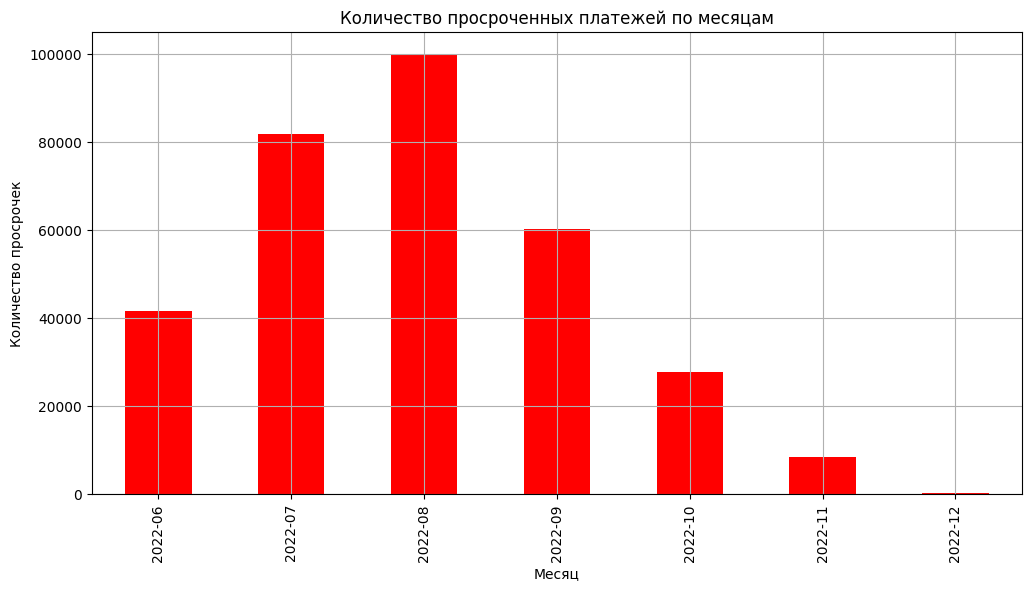

In [8]:
# Сгруппируем по месяцам
by_month = overdue.groupby(
    credits_totals['plan_at'].dt.to_period('M')
)['days_overdue'].count()
# Строим график
plt.figure(figsize=(12, 6))
by_month.plot(kind='bar', color='r', title = "Количество просроченных платежей по месяцам")
plt.xlabel('Месяц')
plt.ylabel('Количество просрочек')
plt.grid(True)
plt.show()

In [9]:
# Доля просроченных платежей
general_payments = len(credits_totals)
overdue_shares = len(overdue) / general_payments * 100
print(f"Доля просроченных платежей: {overdue_shares:.2f}%")

Доля просроченных платежей: 21.58%


In [10]:
#Среднее количество дней просрочки
average_overdue = overdue['days_overdue'].mean()
print('Среднее количество дней просрочки:', average_overdue)

Среднее количество дней просрочки: 39.427467848697546


In [11]:
# Прогнозирование будущих просрочек. Преобразуем данные в подходящие форматы для модели
credits_totals['год'] = credits_totals['plan_at'].dt.year
credits_totals['месяц'] = credits_totals['plan_at'].dt.month
credits_totals['день_недели'] = credits_totals['plan_at'].dt.dayofweek
credits_totals['квартал'] = credits_totals['plan_at'].dt.quarter

In [12]:
# Выделим целевую переменную и фичи
X = credits_totals[['год', 'месяц', 'день_недели', 'квартал']]
y = credits_totals['days_overdue']

In [13]:
# Разделим данные на тренировочную и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
# Создаём объект DMatrix для XGBoost
train_dmatrix = xgb.DMatrix(data=X_train, label=y_train)
test_dmatrix = xgb.DMatrix(data=X_test, label=y_test)

# Параметры модели
params = {
    'max_depth': 3,
    'eta': 0.05,
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse'
}

# Обучаем модель
model_xgb = xgb.train(params=params, dtrain=train_dmatrix, num_boost_round=500)

In [15]:
# Прогнозируем значения на тестовых данных
preds = model_xgb.predict(test_dmatrix)

# Оцениваем RMSE (Root Mean Square Error)
from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(y_test, preds))
print(f"RMSE: {rmse}")

RMSE: 42.41223191898047


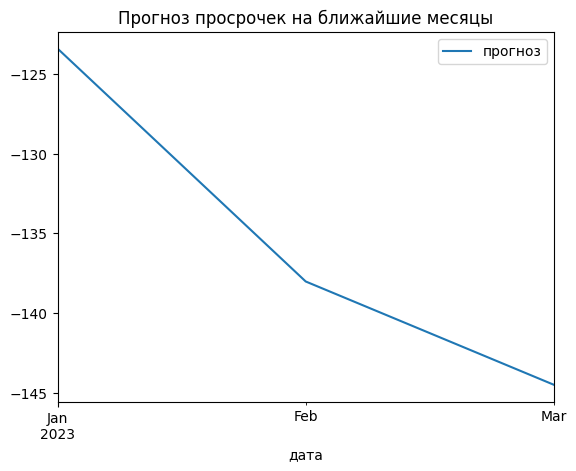

In [16]:
# Предположим, что мы хотим спрогнозировать следующие 3 месяца
future_months = pd.date_range(start='12/09/2022', periods=3, freq='MS')

# Формируем фичи для будущего периода
future_X = pd.DataFrame({
    'год': future_months.year,
    'месяц': future_months.month,
    'день_недели': future_months.dayofweek,
    'квартал': future_months.quarter
})

# Делаем прогноз
future_preds = model_xgb.predict(xgb.DMatrix(future_X))

# Показываем прогноз
pd.DataFrame({'дата': future_months, 'прогноз': future_preds}).set_index('дата').plot(title='Прогноз просрочек на ближайшие месяцы')
plt.show()

Анализ просроченной задолженности
    На основании представленных данных, доля просроченных платежей на текущий момент составляет 21.58% от общего объема обязательств. 
Это значение отражает уровень невыполненных в срок финансовых обязательств клиентами компании.
    Средний показатель количества дней просрочки находится на уровне 39.43 дня, что характеризует период, в течение которого клиенты задерживают 
платежи после наступления срока оплаты. Этот параметр позволяет оценить продолжительность задержки выплат и степень оперативности урегулирования 
проблем с задолженностью.
    Анализ графической динамики просрочек демонстрирует заметное снижение данного показателя во времени. Наблюдаемая тенденция указывает 
на улучшение качества управления дебиторской задолженностью и повышение финансовой дисциплины среди контрагентов. Графики наглядно демонстрируют 
стабилизацию ситуации и постепенное сокращение числа просроченных платежей.
    Прогнозируемые данные подтверждают эту положительную динамику. Согласно прогнозу, снижение уровня просроченных платежей продолжится, что является 
важным сигналом для дальнейшей оптимизации работы с задолженностью. Это позволяет предположить, что предпринятые меры по улучшению системы взыскания 
долгов оказались эффективными и продолжают приносить результаты.
    Таким образом, отчетная информация свидетельствует о позитивных изменениях в области управления задолженностью, что создает предпосылки для 
дальнейшего улучшения финансового положения компании.